# EDA тестовых данных

Смотрим что вообще за картинки в тесте. Разметки нет, и руками размечать тест нельзя, поэтому тут просто смотрим глазами
чтобы понять домен: какие шрифты, фоны, длина строк и тд. Отсюда потом берем параметры для генератора синтетики и препроцессинга.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA = '../data'
IMG_DIR = os.path.join(DATA, 'test', 'images')

files = sorted(os.listdir(IMG_DIR))
print(len(files), files[:3])

20000 ['test_00000.png', 'test_00001.png', 'test_00002.png']


In [2]:
sub = pd.read_csv(os.path.join(DATA, 'sample_submission.csv'))
print(sub.shape)
sub.head()

(20000, 2)


,image_id,p_180
0,test_00000,0.5
1,test_00001,0.5
2,test_00002,0.5
3,test_00003,0.5
4,test_00004,0.5


## Размеры картинок

Собираем ширину, высоту, и заодно простую статистику по яркости/контрасту/цветности.

In [3]:
rows = []
for f in files:
    im = np.asarray(Image.open(os.path.join(IMG_DIR, f)).convert('RGB')).astype(np.float32)
    gray = im.mean(axis=2)
    rows.append({
        'file': f,
        'h': im.shape[0],
        'w': im.shape[1],
        'brightness': gray.mean(),
        'contrast': gray.std(),
        # насколько картинка цветная: средняя разница между max и min каналом
        'saturation': (im.max(axis=2) - im.min(axis=2)).mean(),
    })
df = pd.DataFrame(rows)
df['ar'] = df.w / df.h
df.describe().round(2)

,h,w,brightness,contrast,saturation,ar
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,64.40,357.60,140.30,48.72,30.41,6.22
std,59.34,318.93,52.07,20.29,36.94,4.27
min,10.00,25.00,5.75,2.30,0.00,0.72
25%,27.00,129.00,99.66,33.54,5.76,3.50
50%,42.00,238.00,141.27,47.10,16.25,4.89
75%,76.00,479.25,183.68,62.62,40.99,7.52
max,492.00,1599.00,252.26,119.76,246.57,49.67


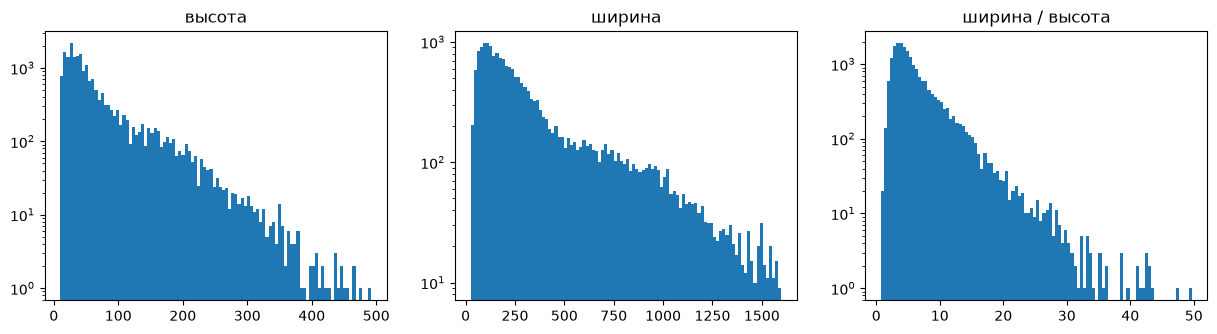

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].hist(df.h, bins=100); ax[0].set_title('высота'); ax[0].set_yscale('log')
ax[1].hist(df.w, bins=100); ax[1].set_title('ширина'); ax[1].set_yscale('log')
ax[2].hist(df.ar, bins=100); ax[2].set_title('ширина / высота'); ax[2].set_yscale('log')
plt.show()

In [5]:
# доли по порогам, пригодится чтоб выбрать размер входа сетки
for t in [4, 6, 8, 10, 12, 16]:
    print(f'w/h > {t}: {(df.ar > t).mean():.3f}')
print()
for t in [16, 24, 32, 48]:
    print(f'h < {t}: {(df.h < t).mean():.3f}')
print()
print('вертикальных (h > w):', (df.h > df.w).sum())

w/h > 4: 0.650
w/h > 6: 0.363
w/h > 8: 0.221
w/h > 10: 0.140
w/h > 12: 0.089
w/h > 16: 0.034

h < 16: 0.048
h < 24: 0.165
h < 32: 0.346
h < 48: 0.552

вертикальных (h > w): 4


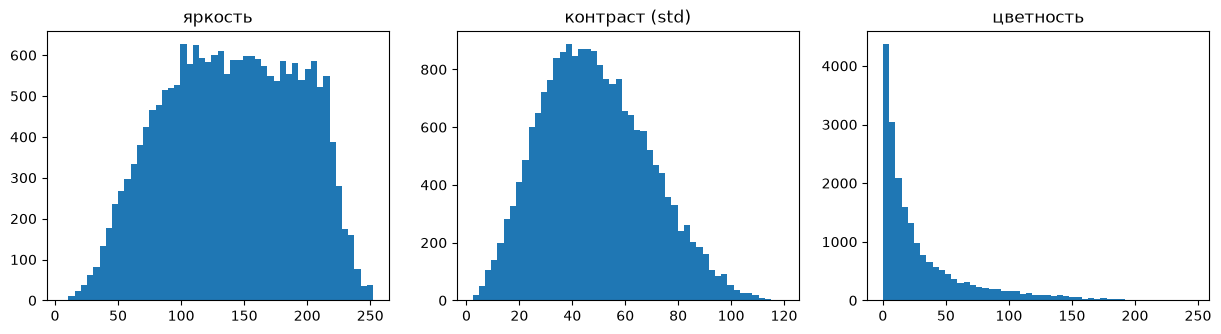

почти серых картинок: 0.374


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].hist(df.brightness, bins=50); ax[0].set_title('яркость')
ax[1].hist(df.contrast, bins=50); ax[1].set_title('контраст (std)')
ax[2].hist(df.saturation, bins=50); ax[2].set_title('цветность')
plt.show()
print('почти серых картинок:', (df.saturation < 10).mean().round(3))

## Смотрим на сами картинки

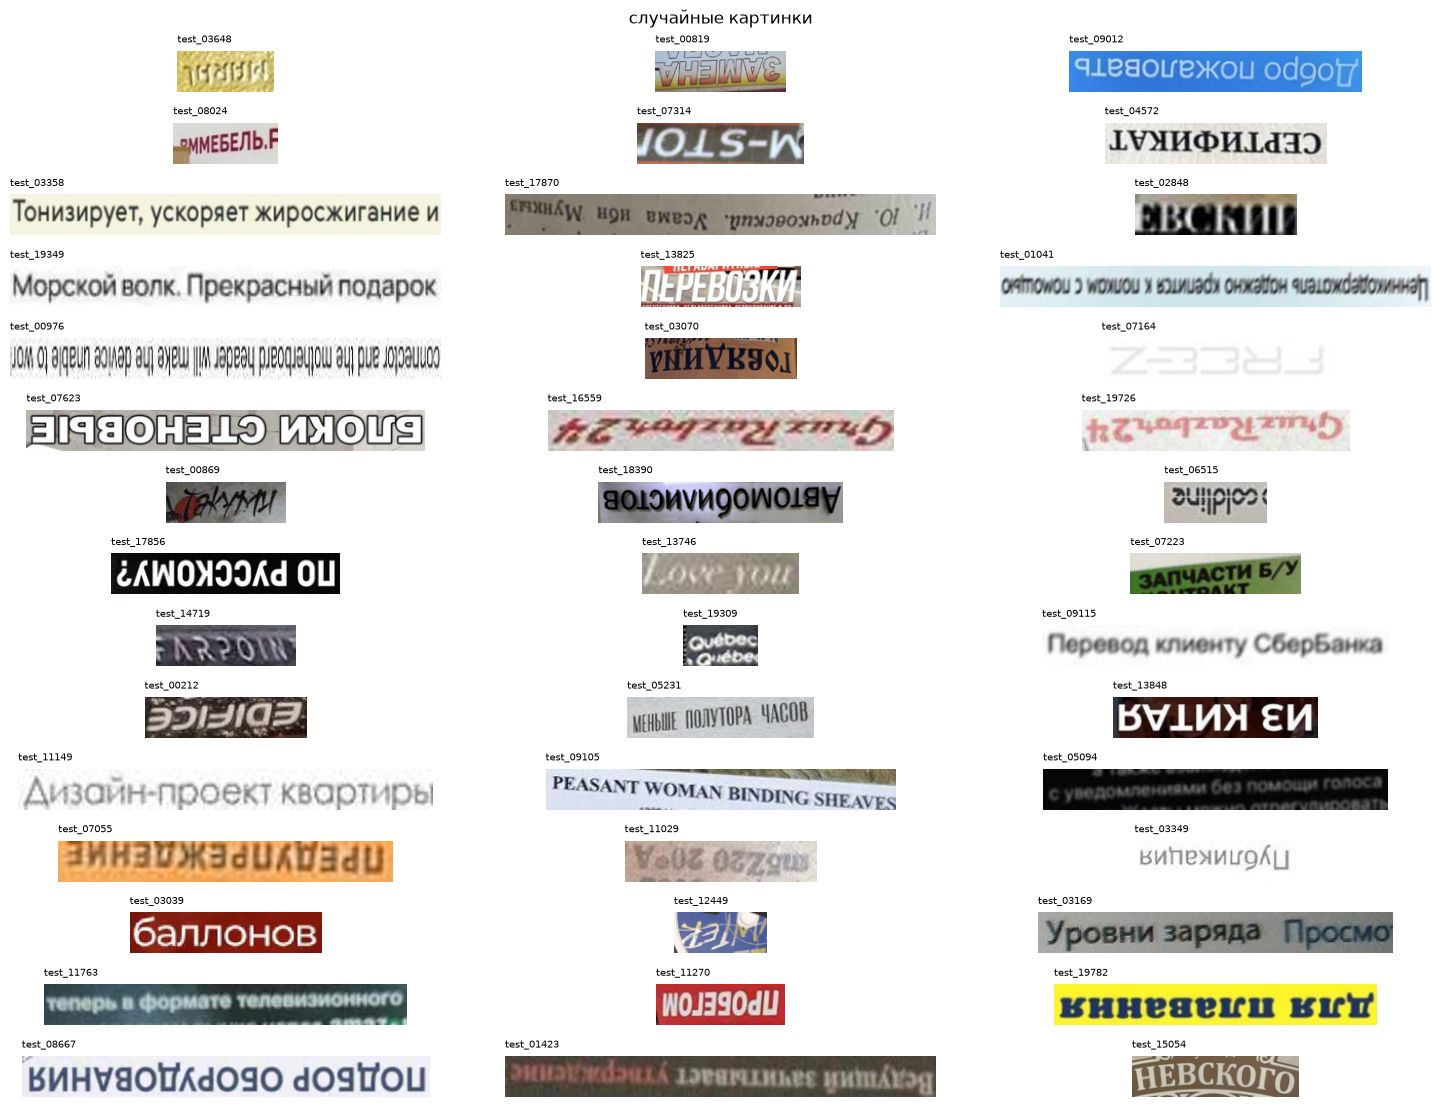

In [7]:
def show_grid(names, ncols=3, h=40, max_w=420, title=None):
    # рисуем картинки сеткой, все приводим к одной высоте чтоб было удобно смотреть
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 0.75 * nrows))
    for ax in axes.ravel():
        ax.axis('off')
    for ax, f in zip(axes.ravel(), names):
        im = Image.open(os.path.join(IMG_DIR, f)).convert('RGB')
        w = min(int(im.width * h / im.height), max_w)
        ax.imshow(im.resize((max(w, 1), h)))
        ax.set_title(f.replace('.png', ''), fontsize=7, loc='left')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

random.seed(42)
show_grid(random.sample(files, 45), title='случайные картинки')

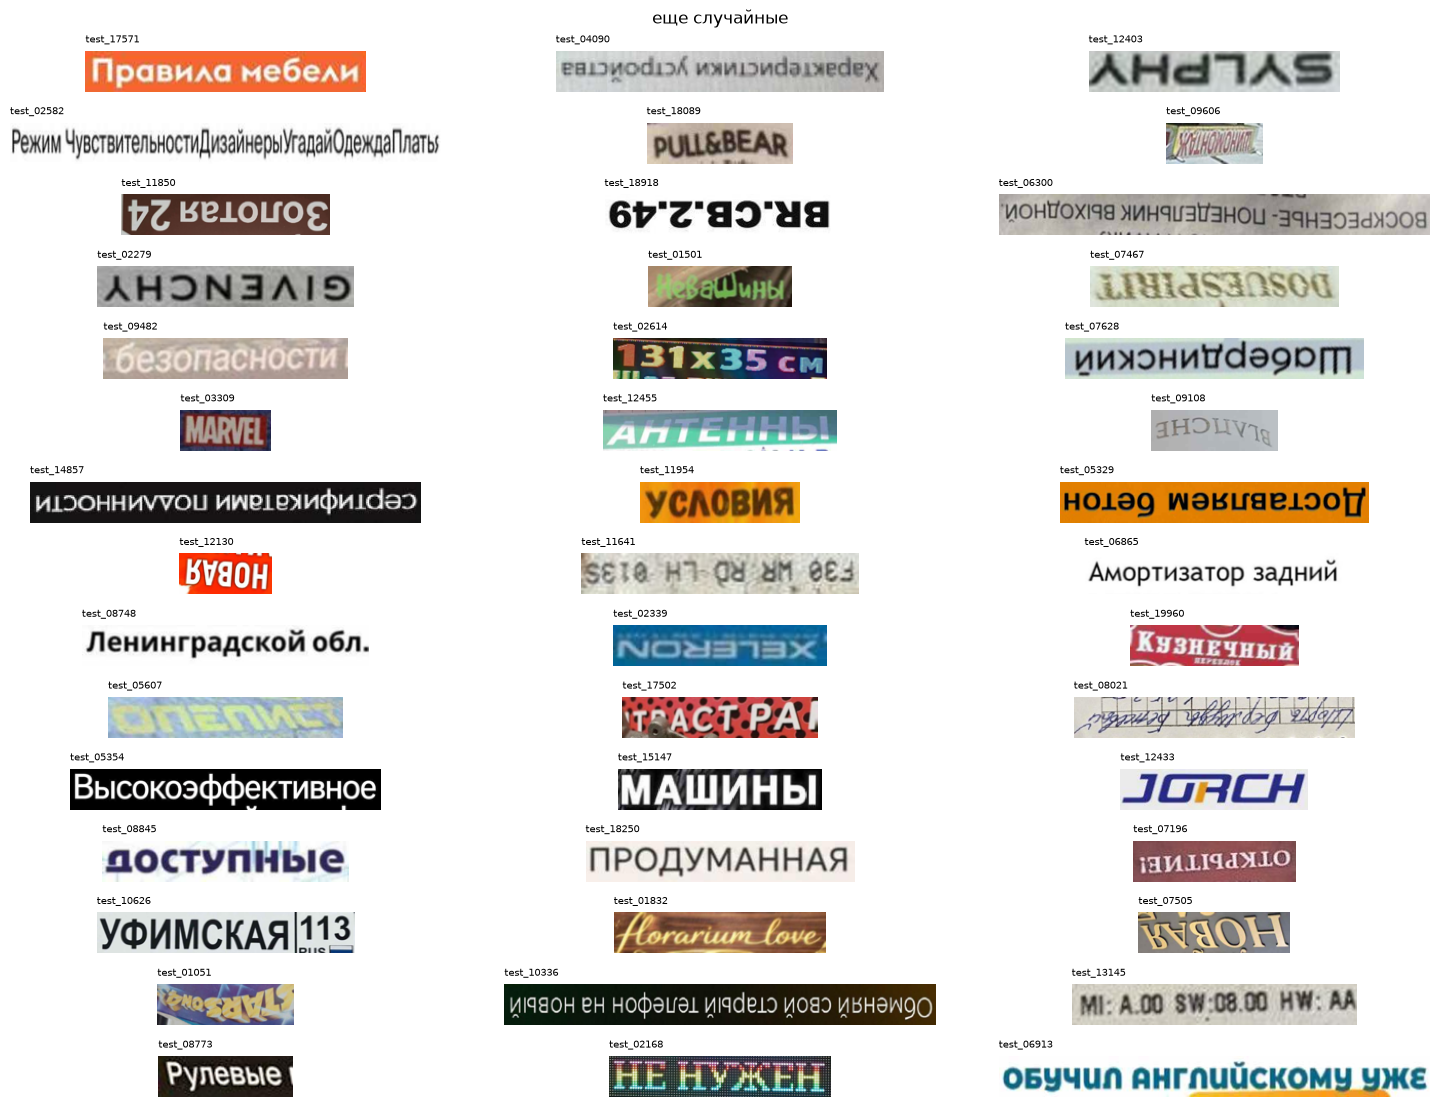

In [8]:
show_grid(random.sample(files, 45), title='еще случайные')

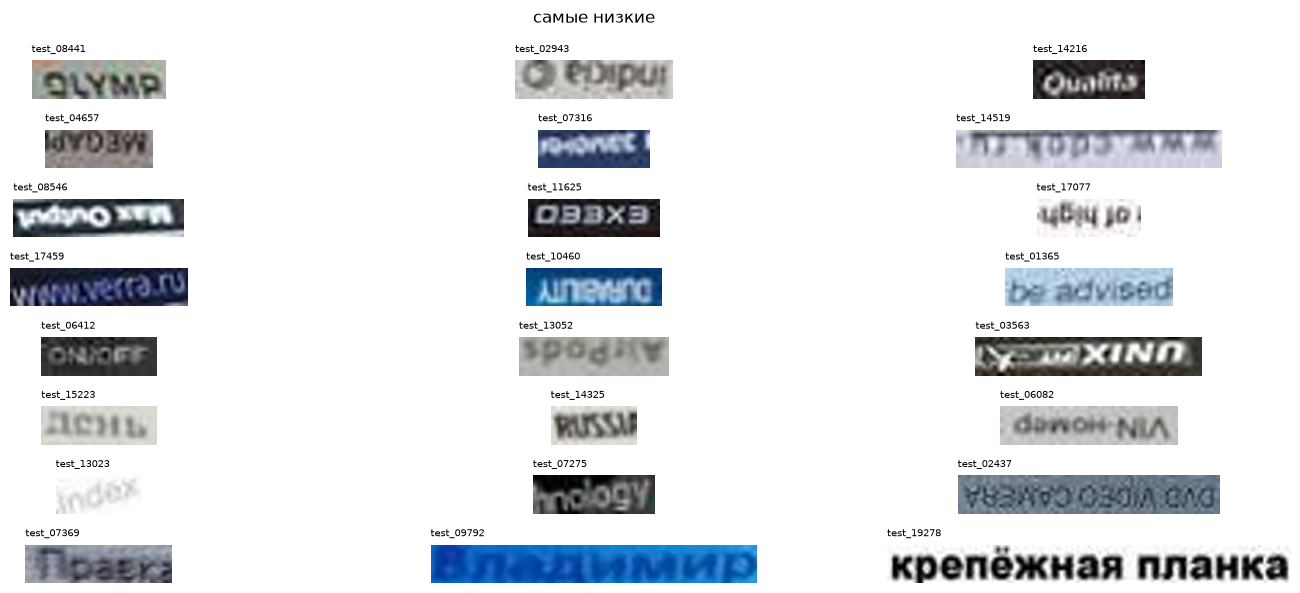

In [9]:
# самые мелкие по высоте
show_grid(df.sort_values('h').file.head(24).tolist(), title='самые низкие')

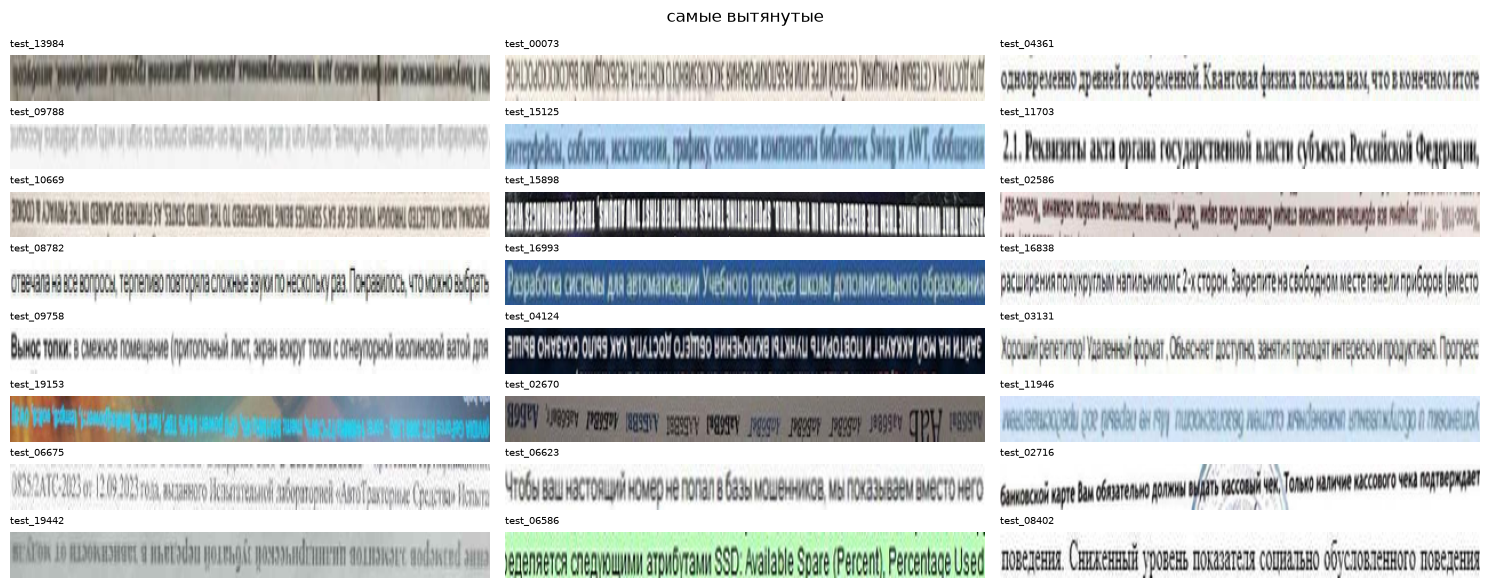

In [10]:
# самые длинные
show_grid(df.sort_values('ar', ascending=False).file.head(24).tolist(), title='самые вытянутые')

## Что видно

* Это реальные кропы с фоток объявлений: вывески, этикетки, упаковки, скриншоты, документы, номера машин,
  серийники, логотипы. Есть рукописный текст.
* Язык в основном русский, но латиницы тоже много (бренды, модели, английские надписи). Цифры отдельно (телефоны, серийники, цены).
* На глаз примерно половина картинок перевернута, то есть классы скорее всего сбалансированы
  (точную долю потом оценим моделью, руками ничего не считаем).
* Бывают куски соседних строк сверху/снизу, т.к боксы от детектора не идеальные.
* Много мелких и размытых картинок, треть ниже 32 пикселей по высоте. Шрифты очень разные, от обычных без засечек до жирных декоративных.
* Вертикального текста почти нет (h > w всего несколько штук), поворот на 90 можно не рассматривать.
* Все файлы png, RGB. Около трети картинок почти серые.

Выводы для решения:
1. Вход сетки: серое изображение, высота 32 (выше смысла мало, треть картинок и так мельче), ширину ресайзим с сохранением пропорций.
   Ограничение по ширине где то 8 высот (256 пикселей), так покрываем почти 80% картинок без сжатия, остальные слегка сжимаем по горизонтали.
2. Синтетика должна быть разнообразной: много шрифтов с кириллицей, цветные фоны, блюр, шум, низкое разрешение, куски соседних строк.
3. Кроме синтетики нужны реальные кропы текста с фоток (пусть даже на английском), чтобы сетка видела реальные артефакты.